In [23]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=3)

In [24]:
Leng = 20.
J = 500
dx = float(Leng)/float(J-1)
x_grid = np.array([j*dx for j in range(J)])

In [25]:
T = 600
N = 8000
dt = float(T)/float(N-1)
t_grid = np.array([n*dt for n in range(N)])

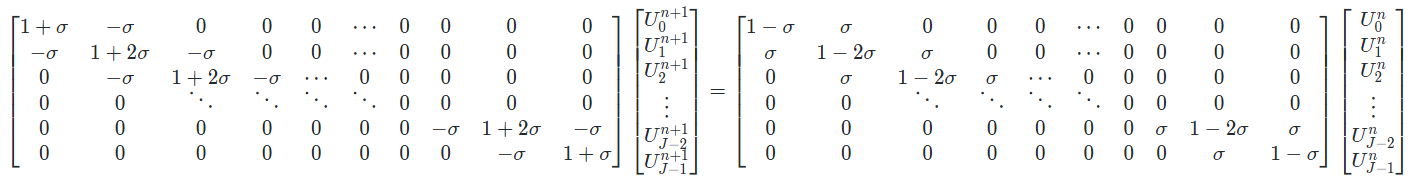

In [66]:
D = float(10.)/float(100.)
C0 = 5
sigma0 = 3
sigma = D*dt/(2*dx**2)

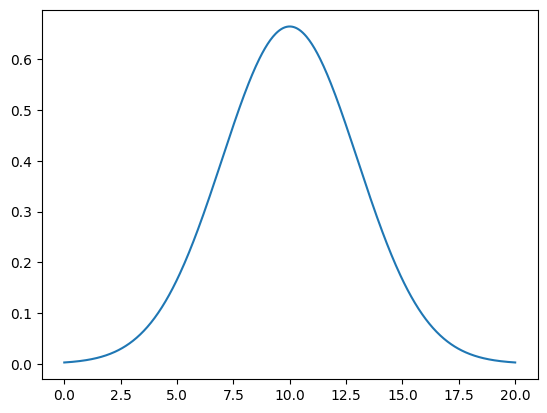

In [67]:
U =  np.array([((C0/(np.sqrt(2*np.pi)*sigma0)))*np.exp(-(dx*i-10)**2/(2*sigma0**2)) for i in range(J)])
plt.plot(x_grid, U)

In [68]:
A = np.diagflat([-sigma for i in range(J-1)], -1) +\
      np.diagflat([1.+sigma]+[1.+2.*sigma for i in range(J-2)]+[1.+sigma]) +\
      np.diagflat([-sigma for i in range(J-1)], 1)

B = np.diagflat([sigma for i in range(J-1)], -1) +\
      np.diagflat([1.-sigma]+[1.-2.*sigma for i in range(J-2)]+[1.-sigma]) +\
      np.diagflat([sigma for i in range(J-1)], 1)
print(A)

[[ 3.335 -2.335  0.    ...  0.     0.     0.   ]
 [-2.335  5.669 -2.335 ...  0.     0.     0.   ]
 [ 0.    -2.335  5.669 ...  0.     0.     0.   ]
 ...
 [ 0.     0.     0.    ...  5.669 -2.335  0.   ]
 [ 0.     0.     0.    ... -2.335  5.669 -2.335]
 [ 0.     0.     0.    ...  0.    -2.335  3.335]]


In [69]:
U_record = []
U_record.append(U)
for ti in range(1,N):
    U_new = np.linalg.solve(A, B.dot(U))
    
    U = U_new
    U_record.append(U)

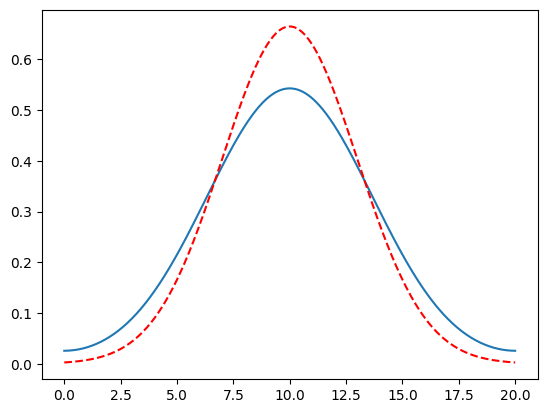

<class 'numpy.ndarray'>


In [74]:
plt.plot(x_grid, U_record[300])
plt.plot(x_grid, U_record[0], linestyle="--", color="r")
plt.show()
print(type(U_record[0]))

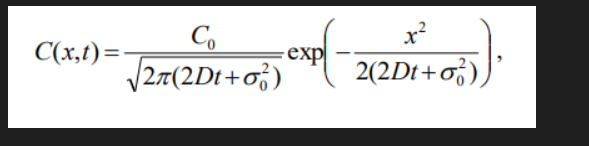

In [32]:
Solution = []
Solution_record=[]
for tm in range(N):
    Solution=[]
    for xc in range(J):
        Solution.append(C0/np.sqrt(2*np.pi*(2*D*dt*tm+sigma0**2))*np.exp(-(dx*xc-10)**2/(2*(2*D*dt*tm+sigma0**2))))
    Solution_record.append(Solution)



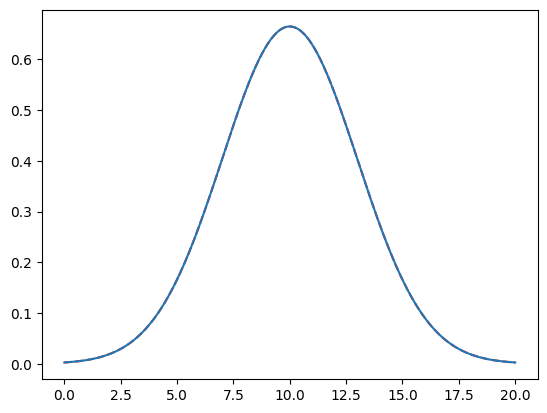

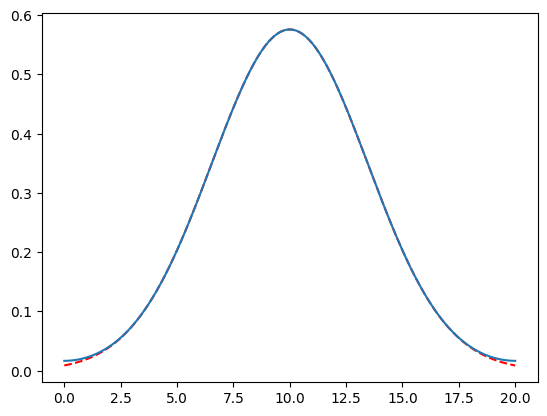

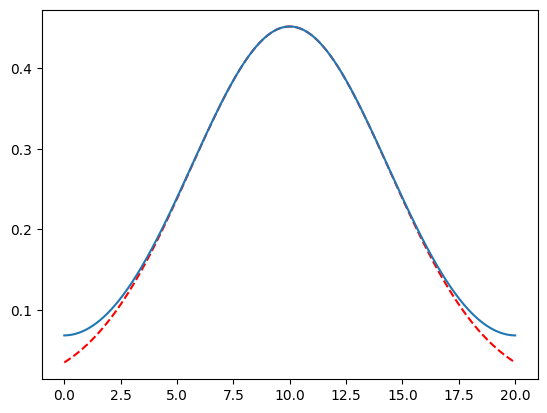

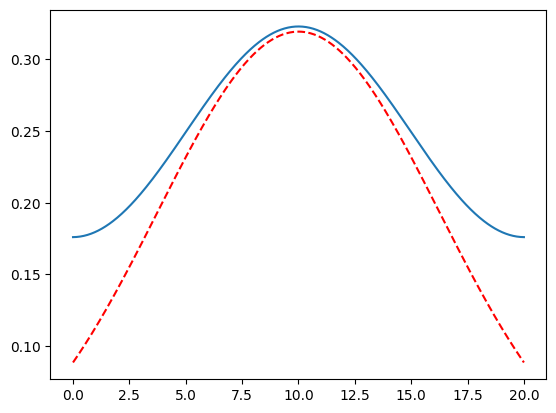

In [81]:
plt.plot(x_grid, Solution_record[0], linestyle="--", color="r")
plt.plot(x_grid, U_record[0])
plt.show()
plt.plot(x_grid, Solution_record[200], linestyle="--", color="r")
plt.plot(x_grid, U_record[200])
plt.show()
plt.plot(x_grid, Solution_record[700], linestyle="--", color="r")
plt.plot(x_grid, U_record[700])
plt.show()
plt.plot(x_grid, Solution_record[2000], linestyle="--", color="r")
plt.plot(x_grid, U_record[2000])
plt.show()


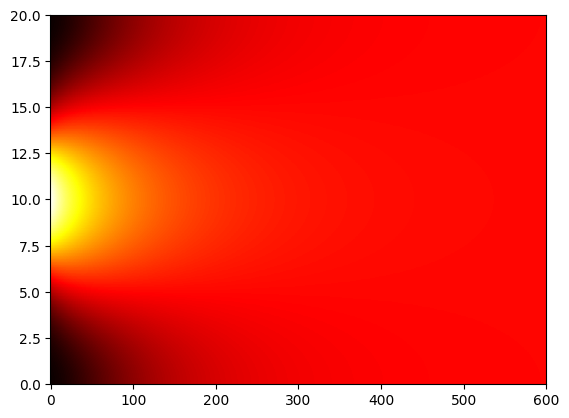

In [83]:
U_record = np.array(U_record)
Xc, Yc= np.meshgrid(x_grid, t_grid)
plt.pcolormesh(Yc, Xc, U_record, cmap='hot')
plt.show()

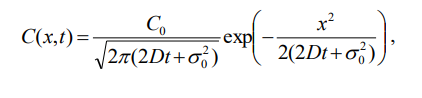

In [80]:
AbsErr = 0
for tm in range(N):
    for xc in range(J):
       AbsErr += abs(U_record[tm][xc]-C0/np.sqrt(2*np.pi*(2*D*dt*tm+sigma0**2))*np.exp(-(dx*xc-10)**2/(2*(2*D*dt*tm+sigma0**2))))
print(f"Average absolute error: {AbsErr/(N*J)}")
print(f"Absolute error ratio to mean concentration density: {round(AbsErr/(N*J)*Leng/C0*100)}%")


Average absolute error: 0.05198407223799608
Absolute error ratio to mean concentration density: 21%
